In [20]:
# import asf_search as asf        # search the ASF catalog
# import earthaccess               # authenticate with NASA Earthdata
# import h5py                      # read HDF5 files
# import numpy as np               # array math
# import rioxarray                 # geospatial arrays + GeoTIFF export
# import xarray as xr              # labeled arrays
# import matplotlib.pyplot as plt  # plotting
# from datetime import datetime
# import geopandas as gpd
# from pathlib import Path
# import warnings; warnings.filterwarnings('ignore')

# print("✓ All imports OK")
# print(f"  asf_search version: {asf.__version__}")

import sys
import os
from pathlib import Path
project_root = str(Path(os.getcwd()).parent)

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
# from scripts.layers import assemble_data, get_uavsar_coherence, get_uavsar_incidence, get_nlcd_layers
from scripts.nisar import download_nisar
from scripts.plotting import plot_tifs_grid 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

Took 3 min for one granule. For 16 granules, I expect it to take 3*16 = about an hour. 

In [11]:
track = 19
frame = 21
start = '2025-12-01'
end = '2026-04-30'

shp = "/bsuhome/julialober/scratch/coherence_data/ASO_EastRiver_shapefile.shp"
out = "/bsuhome/julialober/scratch/coherence_data/nisar/east_river"
layers = ['unwrapped_phase', 'coherence_unwrapped', 'wrapped_phase', 'coherence_wrapped']

# (grans, files) = download_nisar(
#     track=track,
#     frame=frame,
#     start_date=start,
#     end_date=end,
#     aoi=shp,
#     layers=layers,
#     output_dir=out
# )

2026-09-18 16:09:59,579 - INFO - Searching ASF for NISAR GUNW granules: track=19, frame=21, 2025-12-01–2026-04-30
2026-09-18 16:09:59,597 - INFO - SEARCH: Using search opts {
    "frame": [
        21
    ],
    "processingLevel": [
        "GUNW"
    ],
    "relativeOrbit": [
        19
    ],
    "start": "2025-12-01T00:00:00Z",
    "end": "2026-04-30T00:00:00Z",
    "dataset": [
        "NISAR"
    ]
}
2026-09-18 16:09:59,604 - INFO - SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
2026-09-18 16:09:59,604 - INFO - SUBQUERY 1: Beginning subquery with opts: {
    "frame": [
        21
    ],
    "processingLevel": [
        "GUNW"
    ],
    "relativeOrbit": [
        19
    ],
    "start": "2025-12-01T00:00:00Z",
    "end": "2026-04-30T00:00:00Z",
    "collections": [
        "C1256524081-ASFDEV",
        "C1256533420-ASFDEV",
        "C1256535568-ASFDEV",
        "C1256535570-ASFDEV",
        "C1256574227-ASFDEV",
        "C1256578011-ASFDEV",
 

In [37]:
# print(files)
with open('/bsuhome/julialober/scratch/coherence_data/nisar/east_river/filenames.txt', 'r') as file:
    files = file.read().splitlines()

In [38]:
import re
from datetime import datetime 

def parse_dates(filename, pattern=re.compile(r'(\d{8})T\d{6}')):
    dates = pattern.findall(str(filename))
    start = datetime.strptime(dates[0], '%Y%m%d')
    end = datetime.strptime(dates[2], '%Y%m%d')
    days = (end - start).days
    return f"{start.strftime('%Y/%m/%d')} - {end.strftime('%Y/%m/%d')}\n({days} days)"


In [42]:
selected = [f for f in files if 'coherence_unwrapped' in str(f)]
dates = [parse_dates(s) for s in selected]
selected
# dates[::-1]

['/bsuhome/julialober/scratch/coherence_data/nisar/east_river/NISAR_L2_PR_GUNW_006_019_A_021_007_4000_SH_20251123T121116_20251123T121151_20251205T121116_20251205T121151_P05023_N_F_J_001_coherence_unwrapped.tif',
 '/bsuhome/julialober/scratch/coherence_data/nisar/east_river/NISAR_L2_PR_GUNW_006_019_A_021_008_4000_SH_20251123T121116_20251123T121151_20251217T121117_20251217T121152_X05010_N_F_J_001_coherence_unwrapped.tif',
 '/bsuhome/julialober/scratch/coherence_data/nisar/east_river/NISAR_L2_PR_GUNW_007_019_A_021_008_4000_SH_20251205T121116_20251205T121151_20251217T121117_20251217T121152_P05023_N_F_J_001_coherence_unwrapped.tif',
 '/bsuhome/julialober/scratch/coherence_data/nisar/east_river/NISAR_L2_PR_GUNW_008_019_A_021_009_4000_SH_20251217T121117_20251217T121152_20251229T121118_20251229T121152_P05023_N_F_J_001_coherence_unwrapped.tif',
 '/bsuhome/julialober/scratch/coherence_data/nisar/east_river/NISAR_L2_PR_GUNW_008_019_A_021_009_4000_SH_20251217T121117_20251217T121152_20251229T121118

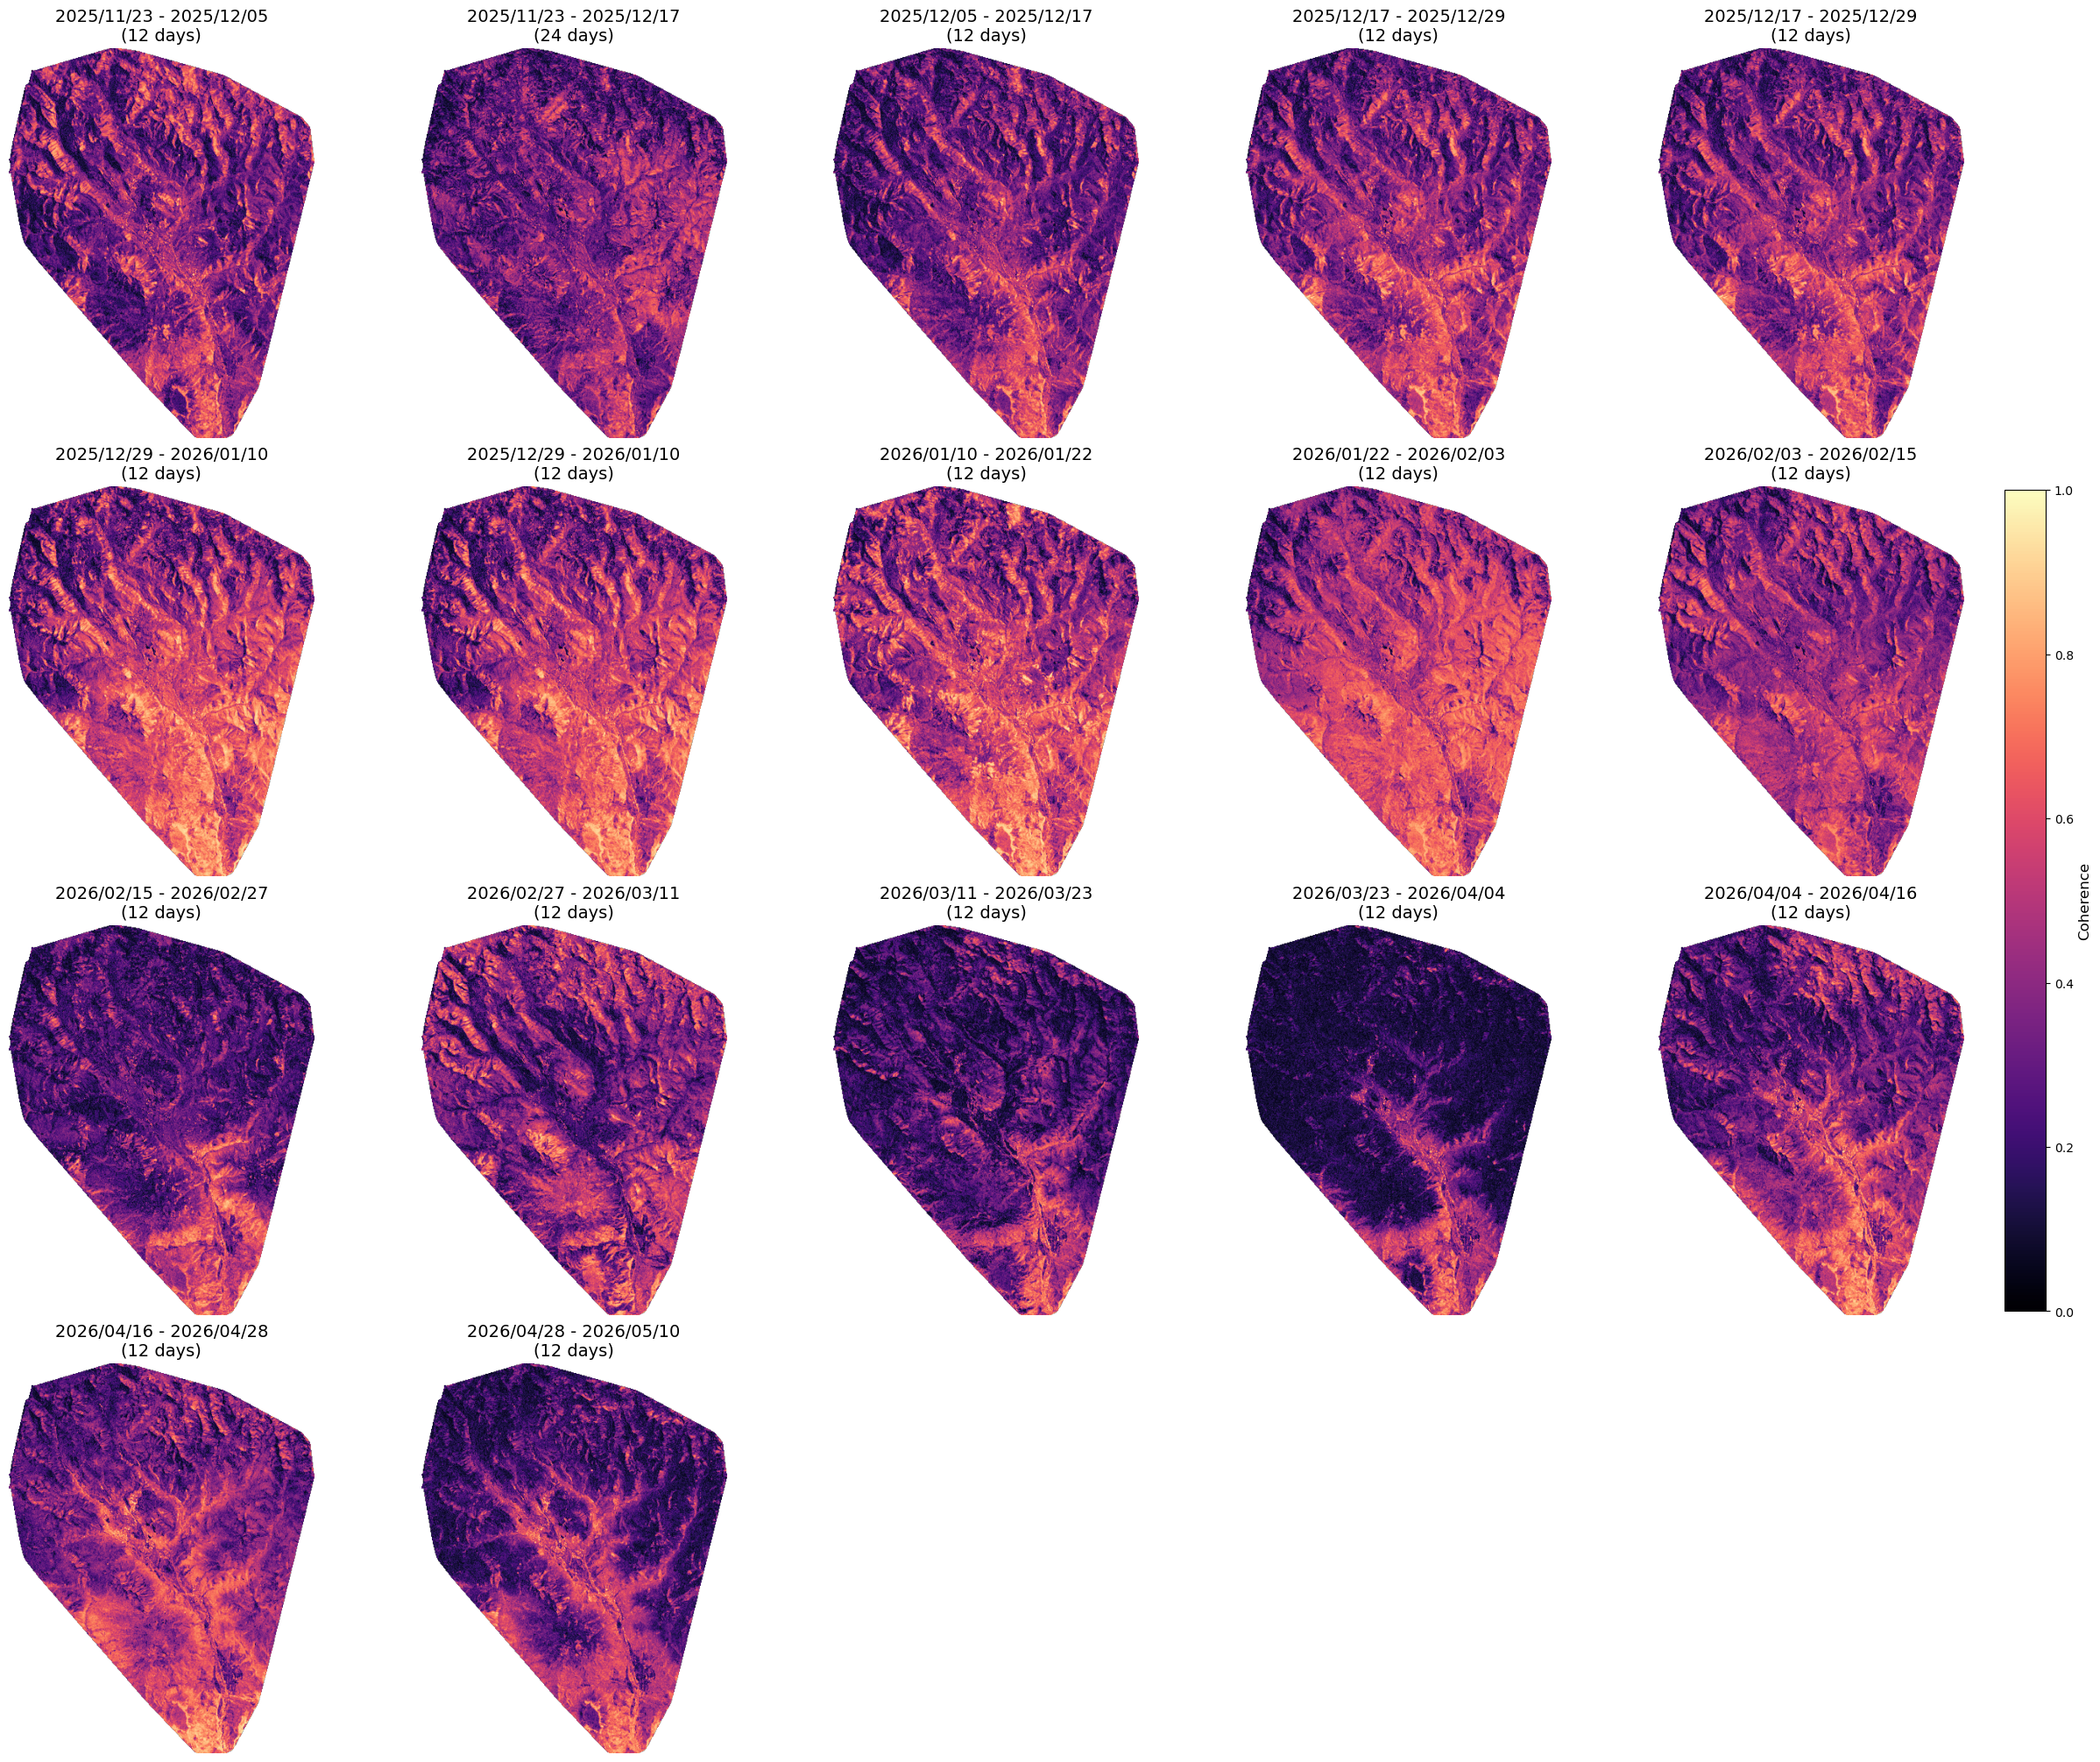

In [43]:
plot_tifs_grid(selected, ncols=5, titles=dates)

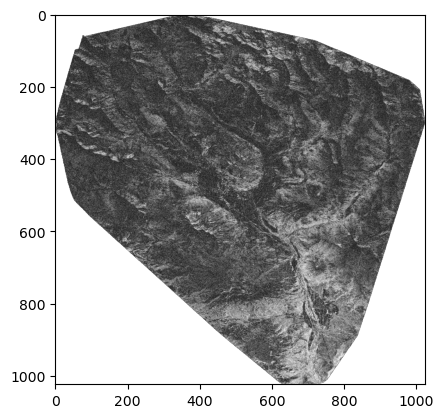

In [9]:
from osgeo import gdal

ds = gdal.Open(files[3])
# Read at reduced resolution directly
buf_xsize, buf_ysize = 1024, 1024
arr = ds.GetRasterBand(1).ReadAsArray(
    buf_xsize=buf_xsize, buf_ysize=buf_ysize
)

import matplotlib.pyplot as plt
plt.imshow(arr, cmap='gray')
plt.show()

In [2]:
# ── Helper: parse interferometric pair dates from GUNW scene name ──
def parse_gunw_dates(scene_name):
    """
    GUNW filenames encode the reference and secondary acquisition dates.
    Example: ...20251221T135101...20260102T135101...
             ↑ reference (Dec 21)   ↑ secondary (Jan 2)
    """
    parts = scene_name.split('_')
    timestamps = [p for p in parts if len(p) == 15 and 'T' in p]
    if len(timestamps) >= 4:
        return timestamps[0][:8], timestamps[2][:8]
    return None, None

def temporal_baseline(scene_name):
    ref, sec = parse_gunw_dates(scene_name)
    if ref and sec:
        return abs((datetime.strptime(sec,'%Y%m%d') -
                    datetime.strptime(ref,'%Y%m%d')).days)
    return None

print("Helper functions defined.")

Helper functions defined.


In [8]:
# [Cell 2]
print("Searching ASF catalog for NISAR GUNW data...")

results = asf.search(
    dataset='NISAR',
    processingLevel='GUNW',
    # relativeOrbit=77,
    # frame=24,
    relativeOrbit=19,
    frame=21,
    start='2026-03-15',
    end='2026-03-21'
)


print(f"Found {len(results)} granules matching criteria.")
print({r.properties['sceneName'] for r in results})

# Select the first ascending granule with full coverage
granule = next(
    r for r in results 
    if r.properties.get('flightDirection') == 'ASCENDING' 
    and r.properties.get('frameCoverage') == 'Full'
)

scene_name = granule.properties['sceneName']
print(f"Selected Scene: {scene_name}")

Searching ASF catalog for NISAR GUNW data...
Found 1 granules matching criteria.
{'NISAR_L2_PR_GUNW_015_019_A_021_016_4000_SH_20260311T121121_20260311T121155_20260323T121121_20260323T121156_P05023_N_F_J_001'}
Selected Scene: NISAR_L2_PR_GUNW_015_019_A_021_016_4000_SH_20260311T121121_20260311T121155_20260323T121121_20260323T121156_P05023_N_F_J_001


In [9]:
granule.properties['url']

'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_PROVISIONAL_V1/NISAR_L2_PR_GUNW_015_019_A_021_016_4000_SH_20260311T121121_20260311T121155_20260323T121121_20260323T121156_P05023_N_F_J_001/NISAR_L2_PR_GUNW_015_019_A_021_016_4000_SH_20260311T121121_20260311T121155_20260323T121121_20260323T121156_P05023_N_F_J_001.h5'

In [20]:
# [Cell 3]
# BASE_URL = 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_BETA_V1'
https_url = granule.properties['url']

# Open HTTPS stream (no data transferred yet)
fs = earthaccess.get_fsspec_https_session()
hf = h5py.File(fs.open(https_url, cache_type='background', block_size=16*1024*1024), 'r')

print(hf)

<HDF5 file "NISAR_L2_PR_GUNW_015_019_A_021_016_4000_SH_20260311T121121_20260311T121155_20260323T121121_20260323T121156_P05023_N_F_J_001.h5>" (mode r)>


In [21]:
BASE_GRIDS = 'science/LSAR/GUNW/grids/frequencyA'
BASE_META  = 'science/LSAR/GUNW/metadata'

# Read coordinate arrays — these are tiny, just 1D arrays
x_80m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/xCoordinates'][:]
y_80m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/yCoordinates'][:]
x_20m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/xCoordinates'][:]
y_20m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/yCoordinates'][:]
x_inc  = hf[f'{BASE_META}/radarGrid/xCoordinates'][:]
y_inc  = hf[f'{BASE_META}/radarGrid/yCoordinates'][:]
epsg   = int(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/projection'][()])

print(f"Projection     : EPSG:{epsg}  (UTM — Universal Transverse Mercator)")
print(f"20m grid       : {len(x_20m)} cols × {len(y_20m)} rows")
print(f"Width          : {(x_80m.max()-x_80m.min())/1000:.0f} km")
print(f"Height         : {abs(y_20m.max()-y_20m.min())/1000:.0f} km")
print(f"Easting        : {x_20m.min():.0f} – {x_20m.max():.0f} m")
print(f"Northing       : {y_20m.min():.0f} – {y_20m.max():.0f} m")
print('-')
print(f"80m grid       : {len(x_80m)} cols × {len(y_80m)} rows")
print(f"Width          : {(x_80m.max()-x_80m.min())/1000:.0f} km")
print(f"Height         : {abs(y_80m.max()-y_80m.min())/1000:.0f} km")
print(f"Easting        : {x_80m.min():.0f} – {x_80m.max():.0f} m")
print(f"Northing       : {y_80m.min():.0f} – {y_80m.max():.0f} m")

Projection     : EPSG:32613  (UTM — Universal Transverse Mercator)
20m grid       : 17640 cols × 17388 rows
Width          : 353 km
Height         : 348 km
Easting        : 241930 – 594710 m
Northing       : 4097530 – 4445270 m
-
80m grid       : 4410 cols × 4347 rows
Width          : 353 km
Height         : 348 km
Easting        : 241960 – 594680 m
Northing       : 4097560 – 4445240 m


In [22]:
def print_hdf5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Dtype: {obj.dtype}")
    else:
        print(f"Group:   {name}")


print("--- HDF5 File Hierarchy ---")
hf.visititems(print_hdf5_structure)

--- HDF5 File Hierarchy ---
Group:   complex64
Group:   science
Group:   science/LSAR
Group:   science/LSAR/GUNW
Group:   science/LSAR/GUNW/grids
Group:   science/LSAR/GUNW/grids/frequencyA
Dataset: science/LSAR/GUNW/grids/frequencyA/centerFrequency | Shape: () | Dtype: float64
Dataset: science/LSAR/GUNW/grids/frequencyA/listOfPolarizations | Shape: (1,) | Dtype: |S2
Group:   science/LSAR/GUNW/grids/frequencyA/pixelOffsets
Group:   science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/alongTrackOffset | Shape: (4347, 4410) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/correlationSurfacePeak | Shape: (4347, 4410) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/projection | Shape: () | Dtype: uint32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/slantRangeOffset | Shape: (4347, 4410) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/

In [23]:
# Define paths for the requested 80m and 20m layers
paths = {
    'unwrapped_phase_80m': f'{BASE_GRIDS}/unwrappedInterferogram/HH/unwrappedPhase',
    'coherence_80m': f'{BASE_GRIDS}/unwrappedInterferogram/HH/coherenceMagnitude',
    'wrapped_phase_20m': f'{BASE_GRIDS}/wrappedInterferogram/HH/wrappedInterferogram',
    'coherence_20m': f'{BASE_GRIDS}/wrappedInterferogram/HH/coherenceMagnitude'
}

print("Checking RAM footprint before downloading...")
for name, path in paths.items():
    if path in hf:
        print(f'Checking {path}')
        ds = hf[path]
        ram_mb = (ds.size * ds.dtype.itemsize) / 1e6
        print(f"  {name}: {ds.shape} | Expected RAM: {ram_mb:.1f} MB")

Checking RAM footprint before downloading...
Checking science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/unwrappedPhase
  unwrapped_phase_80m: (4347, 4410) | Expected RAM: 76.7 MB
Checking science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/coherenceMagnitude
  coherence_80m: (4347, 4410) | Expected RAM: 76.7 MB
Checking science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/wrappedInterferogram
  wrapped_phase_20m: (17388, 17640) | Expected RAM: 2453.8 MB
Checking science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/coherenceMagnitude
  coherence_20m: (17388, 17640) | Expected RAM: 1226.9 MB


In [24]:
def get_clipped_da(ds_path, x_coords, y_coords, name, epsg, clip_geom=None):
    """Reads HDF5 dataset, masks no-data, wraps in DataArray, and optionally clips."""
    ds = hf[ds_path]
    data = ds[:].astype(np.float32)
    
    # Mask fill values and zeros
    fv = ds.attrs.get('_FillValue', None)
    if fv is not None:
        data = np.where(data == fv, np.nan, data)
    data[data == 0] = np.nan
    
    # Create DataArray
    da = xr.DataArray(data, dims=['y', 'x'], coords={'x': x_coords, 'y': y_coords}, name=name)
    da = da.rio.write_crs(f'EPSG:{epsg}').rio.write_nodata(np.nan)
    
    return da.rio.clip(clip_geom, all_touched=True, drop=True) if clip_geom is not None else da

# ── 2. Load and Reproject Bounding Shapefile ──
print("Loading and reprojecting shapefile boundary...")
# Assuming epsg is defined earlier in your notebook (e.g., epsg = 32611)
shapefile_path = "/bsuhome/julialober/scratch/coherence_data/ASO_EastRiver_shapefile.shp"
mores_boundary = gpd.read_file(shapefile_path).to_crs(f'EPSG:{epsg}')
geometries = mores_boundary.geometry

# ── 3. Read and Clip Layers Directly ──
print("Reading and clipping 80m layers...")

unwrapped_80m = get_clipped_da(
    paths['unwrapped_phase_80m'],
    x_80m, y_80m, 'unwrapped_phase', epsg, clip_geom=geometries
)

coherence_80m = get_clipped_da(
    paths['coherence_80m'], 
    x_80m, y_80m, 'coherence', epsg, clip_geom=geometries
)

print("Reading and clipping 20m layers...")

wrapped_20m = get_clipped_da(
    paths['wrapped_phase_20m'], 
    x_20m, y_20m, 'wrapped_phase', epsg, clip_geom=geometries
)

coherence_20m = get_clipped_da(
    paths['coherence_20m'], 
    x_20m, y_20m, 'coherence', epsg, clip_geom=geometries
)

# Incidence angle requires finding the correct height index first
heights = hf[f'{BASE_META}/radarGrid/heightAboveEllipsoid'][:]
gidx = int(np.argmin(np.abs(heights)))
inc_data = hf[f'{BASE_META}/radarGrid/incidenceAngle'][gidx].astype(np.float32)
inc_data[inc_data == 0] = np.nan

da_inc = xr.DataArray(inc_data, dims=['y', 'x'], coords={'x': x_inc, 'y': y_inc}, name='incidence_angle')
da_inc = da_inc.rio.write_crs(f'EPSG:{epsg}').rio.write_nodata(np.nan)
incidence_clip = da_inc.rio.clip(geometries, all_touched=True, drop=True)

hf.close()

Loading and reprojecting shapefile boundary...
Reading and clipping 80m layers...


Reading and clipping 20m layers...


In [25]:

# ── 4. Summary ──
print(f"\n✓ Stream closed. Layers clipped to Mores Creek.")
print(f"  Clipped Shape  (Unwrapped): {unwrapped_80m.shape}")
print(f"  Clipped Bounds (Unwrapped): {unwrapped_80m.rio.bounds()}")

print(f"  Clipped Shape  (Wrapped): {wrapped_20m.shape}")
print(f"  Clipped Bounds (Wrapped): {wrapped_20m.rio.bounds()}")

clip_ram = (unwrapped_80m.nbytes + coherence_80m.nbytes) / 1e6
print(f"  Clipped RAM   : {clip_ram:.1f} MB")


✓ Stream closed. Layers clipped to Mores Creek.
  Clipped Shape  (Unwrapped): (518, 406)
  Clipped Bounds (Unwrapped): (316080.0, 4281040.0, 348560.0, 4322480.0)
  Clipped Shape  (Wrapped): (2069, 1618)
  Clipped Bounds (Wrapped): (316140.0, 4281080.0, 348500.0, 4322460.0)
  Clipped RAM   : 1.7 MB


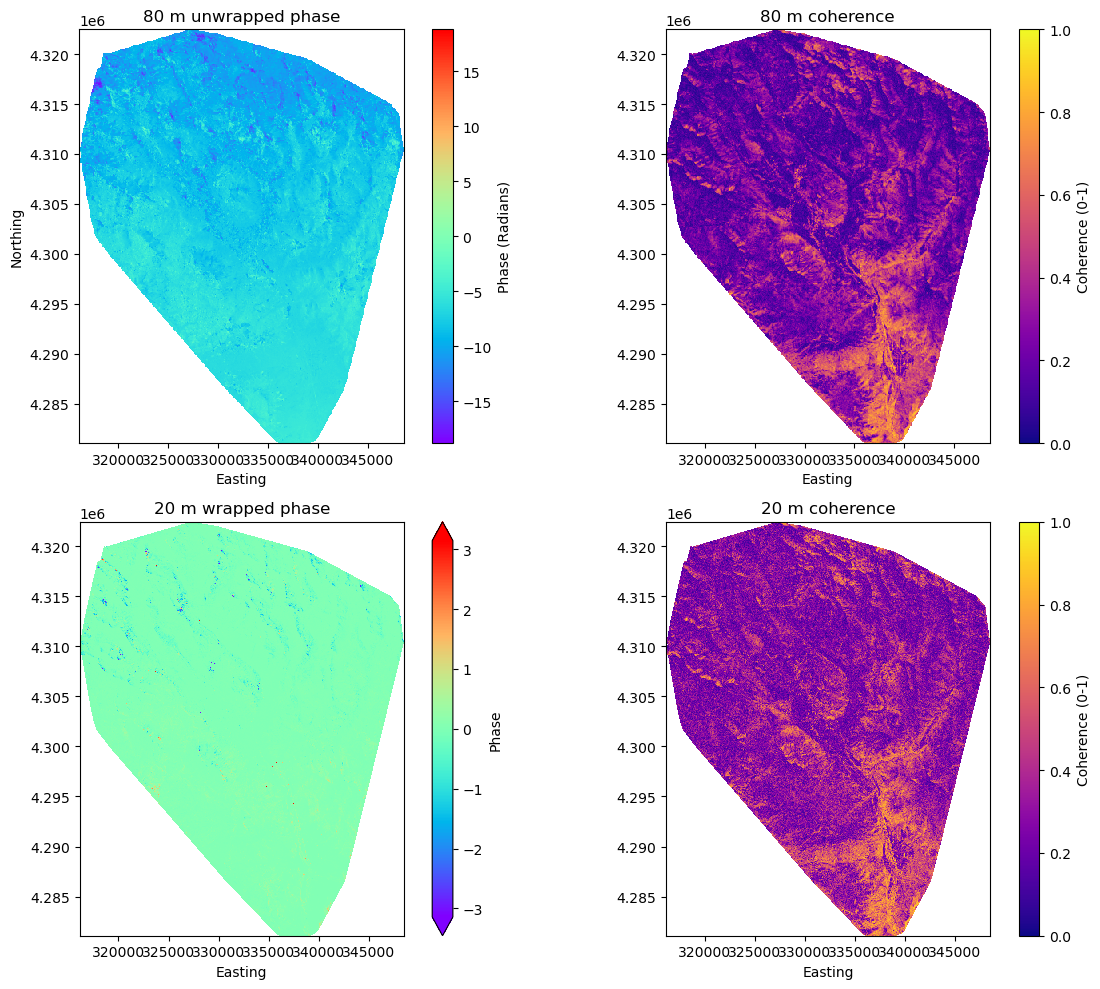

In [26]:
# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# ── 1. Plot Unwrapped Phase ──
# Unwrapped phase represents relative ground displacement (continuous values)
unwrapped_80m.plot(
    ax=axes[0], 
    cmap='rainbow', 
    cbar_kwargs={'label': 'Phase (Radians)'}
)
axes[0].set_title('80 m unwrapped phase')
axes[0].set_aspect('equal') # Maintains proper spatial proportions
axes[0].set_xlabel('Easting')
axes[0].set_ylabel('Northing')

# ── 2. Plot Coherence Magnitude ──
# Coherence ranges from 0 (noise, decorrelation) to 1 (perfect correlation)
coherence_80m.plot(
    ax=axes[1], 
    cmap='plasma', 
    vmin=0, 
    vmax=1, 
    cbar_kwargs={'label': 'Coherence (0-1)'}
)
axes[1].set_title('80 m coherence')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Easting')
axes[1].set_ylabel('') # Hide y-label to avoid redundancy 

wrapped_20m.plot(
    ax=axes[2], 
    cmap='rainbow', 
    vmin=-np.pi, 
    vmax=np.pi,
    cbar_kwargs={'label': 'Phase'}
)
axes[2].set_title('20 m wrapped phase')
axes[2].set_aspect('equal')
axes[2].set_xlabel('Easting')
axes[2].set_ylabel('') # Hide y-label to avoid redundancy 

coherence_20m.plot(
    ax=axes[3], 
    cmap='plasma', 
    vmin=0, 
    vmax=1, 
    cbar_kwargs={'label': 'Coherence (0-1)'}
)
axes[3].set_title('20 m coherence')
axes[3].set_aspect('equal')
axes[3].set_xlabel('Easting')
axes[3].set_ylabel('') # Hide y-label to avoid redundancy 

plt.tight_layout()
plt.show()

In [27]:
coherence_difference = coherence_20m - coherence_80m.rio.reproject_match(coherence_20m)


Text(0, 0.5, '')

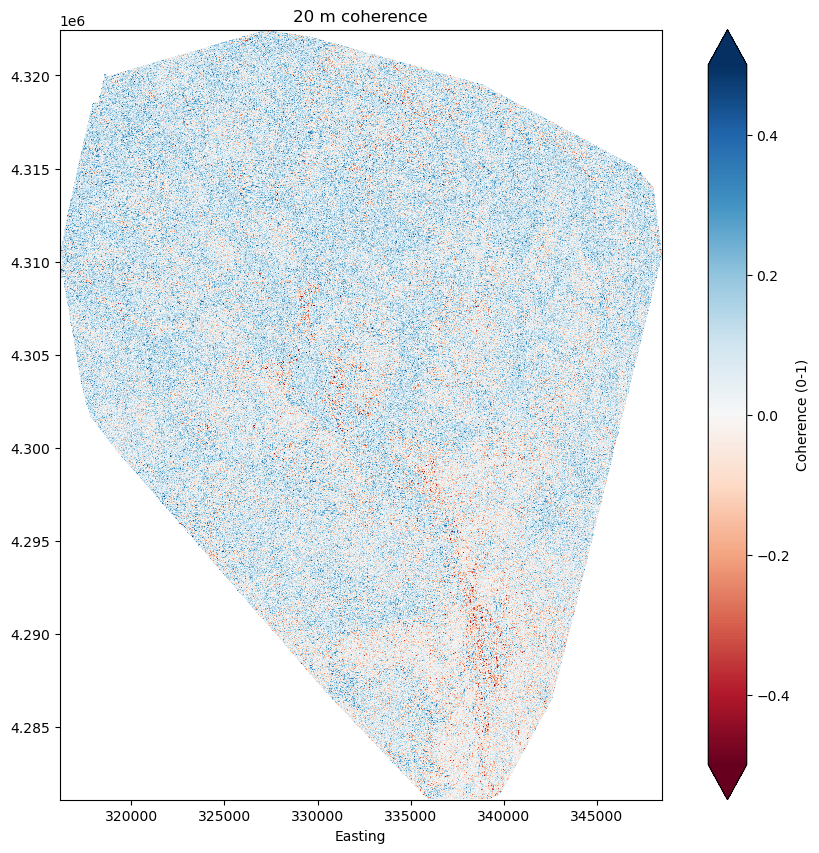

In [29]:
fig, ax = plt.subplots(figsize=(12, 10))

coherence_difference.plot(
    ax=ax, 
    cmap='RdBu', 
    cbar_kwargs={'label': 'Coherence (0-1)'},
    vmin=-0.5, 
    vmax=0.5
)
ax.set_title('20 m coherence')
ax.set_aspect('equal')
ax.set_xlabel('Easting')
ax.set_ylabel('') # Hide y-label to avoid redundancy 